# Bakken Production Trend Analysis and Oil Production Forecast

**Historical period:** May 2003 – December 2025
**Forecast horizon:** January 2026 – December 2027

1. Executive summary metrics
2. Dataset scope and variable definitions
3. Data quality and preprocessing
4. Monthly oil production history
5. Annual oil production and decline
6. Gas and water production trends
7. Well activity and average productivity
8. Gas-oil ratio and water-cut behavior
9. Well-level production performance
10. Forecast methodology and model selection
11. Backtest validation
12. Production forecast for 2026-2027
13. Monthly forecast, limitations and conclusions

**Input file:** `DCA_DATA.xlsx` (columns: `API #`, `C`, `RptDate`, `Formation`, `Lease_Unit`, `BBLS_OIL_COND`, `MCF_GAS`, `BBLS_WTR`, `DAYS_PROD`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_PATH = "DCA_DATA.xlsx"   # <-- update path if the workbook is elsewhere
np.random.seed(42)

## 2. Dataset scope and variable definitions

Each row represents one well production record for a reporting month.

| Column | Interpretation |
|---|---|
| `API #` | Unique well identifier |
| `C` | Time field imported as 12:00 AM for every row; carries no analytical information |
| `RptDate` | End-of-month reporting date for the production period |
| `Formation` | Producing geological formation (Bakken for all records) |
| `Lease_Unit` | Lease or unit identifier |
| `BBLS_OIL_COND` | Monthly oil / condensate volume, barrels |
| `MCF_GAS` | Monthly natural-gas volume, thousand cubic feet |
| `BBLS_WTR` | Monthly produced-water volume, barrels |
| `DAYS_PROD` | Number of producing days reported for the well that month |

In [2]:
df_raw = pd.read_excel(DATA_PATH)
df_raw.columns = [c.strip() for c in df_raw.columns]

print(f"Raw records: {len(df_raw):,}")
print(f"Unique wells (API #): {df_raw['API #'].nunique()}")
df_raw.head()

Raw records: 29,692
Unique wells (API #): 130


,API #,C,RptDate,Formation,Lease_Unit,BBLS_OIL_COND,MCF_GAS,BBLS_WTR,DAYS_PROD
0,25-083-22423-00-00,00:00:00,6/30/2025,Bakken,7341,820,3116,147,30
1,25-083-22423-00-00,00:00:00,5/31/2025,Bakken,7341,851,3025,156,31
2,25-083-22423-00-00,00:00:00,4/30/2025,Bakken,7341,844,3234,140,30
3,25-083-22423-00-00,00:00:00,3/31/2025,Bakken,7341,895,3456,150,31
4,25-083-22423-00-00,00:00:00,2/28/2025,Bakken,7341,834,3194,156,28


## 3. Data quality and preprocessing

Data-quality checks are computed on the **raw** workbook (before duplicate removal), matching the report's Section 3 table. Exact duplicates are then removed; negative production values are retained as likely reporting corrections/reversals.

In [3]:
n_raw = len(df_raw)

# Quality checks on raw data
n_days_gt31   = (df_raw['DAYS_PROD'] > 31).sum()
n_days_eq0    = (df_raw['DAYS_PROD'] == 0).sum()
n_neg_oil     = (df_raw['BBLS_OIL_COND'] < 0).sum()
n_neg_water   = (df_raw['BBLS_WTR'] < 0).sum()
n_missing     = df_raw.isna().sum().sum()

# Exact duplicates
n_dupe = df_raw.duplicated().sum()
dupe_apis = df_raw[df_raw.duplicated(keep=False)]['API #'].unique()

df = df_raw.drop_duplicates().reset_index(drop=True)
n_clean = len(df)

quality_table = pd.DataFrame({
    'Check': ['Raw records', 'Exact duplicate records', 'Clean records', 'Missing values',
              'DAYS_PROD > 31', 'DAYS_PROD = 0', 'Negative oil values', 'Negative water values'],
    'Result': [n_raw, n_dupe, n_clean, n_missing, n_days_gt31, n_days_eq0, n_neg_oil, n_neg_water]
})
print(f"Duplicate rows all belong to API: {list(dupe_apis)}")
quality_table

Duplicate rows all belong to API: ['25-083-22199-00-00']


,Check,Result
0,Raw records,29692
1,Exact duplicate records,250
2,Clean records,29442
3,Missing values,0
4,DAYS_PROD > 31,1
5,DAYS_PROD = 0,1135
6,Negative oil values,5
7,Negative water values,10


In [4]:
# Preprocessing: parse dates, sort, build Month/Year keys
df['RptDate'] = pd.to_datetime(df['RptDate'])
df = df.sort_values('RptDate').reset_index(drop=True)
df['Month'] = df['RptDate'].values.astype('datetime64[M]')   # first-of-month key
df['Year'] = df['RptDate'].dt.year

print(f"Clean history: {df['RptDate'].min():%B %Y} - {df['RptDate'].max():%B %Y}")
print(f"Clean records: {len(df):,}   Unique wells: {df['API #'].nunique()}")

Clean history: May 2003 - December 2025
Clean records: 29,442   Unique wells: 130


## 4. Monthly oil production history

Field-level monthly aggregation: sum oil/gas/water across all wells reporting each month, define an **active well** as a row with `DAYS_PROD > 0`, and compute calendar-day field rate (BOPD) by dividing monthly oil by the number of calendar days in that month.

In [5]:
active_flags = df.assign(is_active=df['DAYS_PROD'] > 0)

monthly = df.groupby('Month').agg(
    oil=('BBLS_OIL_COND', 'sum'),
    gas=('MCF_GAS', 'sum'),
    water=('BBLS_WTR', 'sum'),
).reset_index()

active_wells_monthly = (active_flags[active_flags['is_active']]
                         .groupby('Month')['API #'].nunique()
                         .reindex(monthly['Month']).fillna(0).astype(int))
monthly['active_wells'] = active_wells_monthly.values

monthly['calendar_days'] = monthly['Month'].dt.days_in_month
monthly['field_bopd'] = monthly['oil'] / monthly['calendar_days']
monthly['oil_ma12'] = monthly['oil'].rolling(12).mean()
monthly = monthly.sort_values('Month').reset_index(drop=True)

peak_month = monthly.loc[monthly['oil'].idxmax()]
print(f"Peak monthly oil: {peak_month['oil']:,.0f} bbl ({peak_month['Month']:%B %Y})")
monthly.tail()

Peak monthly oil: 333,099 bbl (December 2006)


,Month,oil,gas,water,active_wells,calendar_days,field_bopd,oil_ma12
267,2025-08-01,41907,80991,28321,122,31,1351.838710,48051.250000
268,2025-09-01,40137,72945,28863,122,30,1337.900000,47585.666667
269,2025-10-01,42073,72521,25315,123,31,1357.193548,46405.583333
270,2025-11-01,41835,72336,24353,121,30,1394.500000,45129.916667
271,2025-12-01,44644,75319,31193,123,31,1440.129032,44607.416667


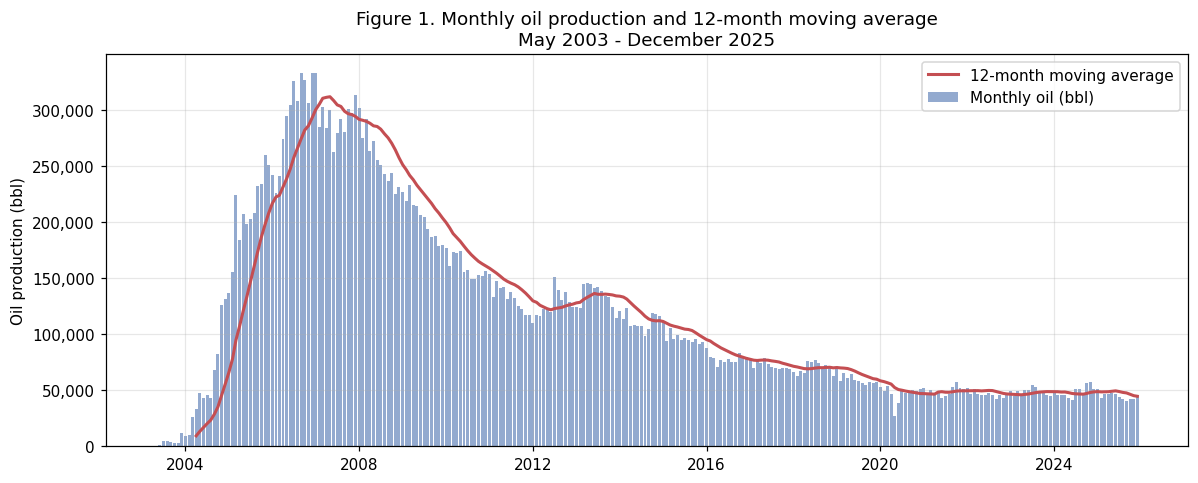

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(monthly['Month'], monthly['oil'], width=25, color='#4C72B0', alpha=0.6, label='Monthly oil (bbl)')
ax.plot(monthly['Month'], monthly['oil_ma12'], color='#C44E52', linewidth=2, label='12-month moving average')
ax.set_title('Figure 1. Monthly oil production and 12-month moving average\nMay 2003 - December 2025')
ax.set_ylabel('Oil production (bbl)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

**Trend interpretation**
- 2003–2007: rapid development and production build-up
- 2007–2013: high production followed by gradual decline and temporary stabilization
- 2014–2020: stronger decline, with a pronounced fall in 2020
- 2021–2024: relatively stable field output around 0.56–0.59 million bbl/year
- 2025: renewed decline, with monthly oil generally between about 40,000 and 51,000 bbl

## 5. Annual oil production and decline

In [7]:
annual = df.groupby('Year').agg(
    oil=('BBLS_OIL_COND', 'sum'),
    gas=('MCF_GAS', 'sum'),
    water=('BBLS_WTR', 'sum'),
).reset_index()
annual['yoy'] = annual['oil'].pct_change() * 100

avg_active = (active_flags[active_flags['is_active']]
              .groupby('Month')['API #'].nunique()
              .rename('active_wells').reset_index())
avg_active['Year'] = avg_active['Month'].dt.year
avg_active_by_year = avg_active.groupby('Year')['active_wells'].mean().rename('avg_active_wells')
annual = annual.merge(avg_active_by_year, on='Year', how='left')

peak_annual = annual.loc[annual['oil'].idxmax()]
last_year = annual.iloc[-1]
decline_from_peak = (last_year['oil'] / peak_annual['oil'] - 1) * 100

print(f"Peak annual oil: {peak_annual['oil']:,.0f} bbl ({int(peak_annual['Year'])})")
print(f"{int(last_year['Year'])} oil: {last_year['oil']:,.0f} bbl "
      f"({decline_from_peak:.1f}% vs. peak)")
print(f"Cumulative oil (2003-2025): {annual['oil'].sum():,.0f} bbl")

annual[annual['Year'].isin([2004, 2007, 2010, 2015, 2020, 2024, 2025])][
    ['Year', 'oil', 'yoy', 'avg_active_wells']
].round(1)

Peak annual oil: 3,528,543 bbl (2007)
2025 oil: 535,289 bbl (-84.8% vs. peak)
Cumulative oil (2003-2025): 31,715,605 bbl


,Year,oil,yoy,avg_active_wells
1,2004,665297,1901.3,9.2
4,2007,3528543,0.5,91.0
7,2010,1928850,-21.1,114.7
12,2015,1165377,-13.3,122.0
17,2020,564502,-21.4,120.1
21,2024,582214,-0.4,123.2
22,2025,535289,-8.1,123.2


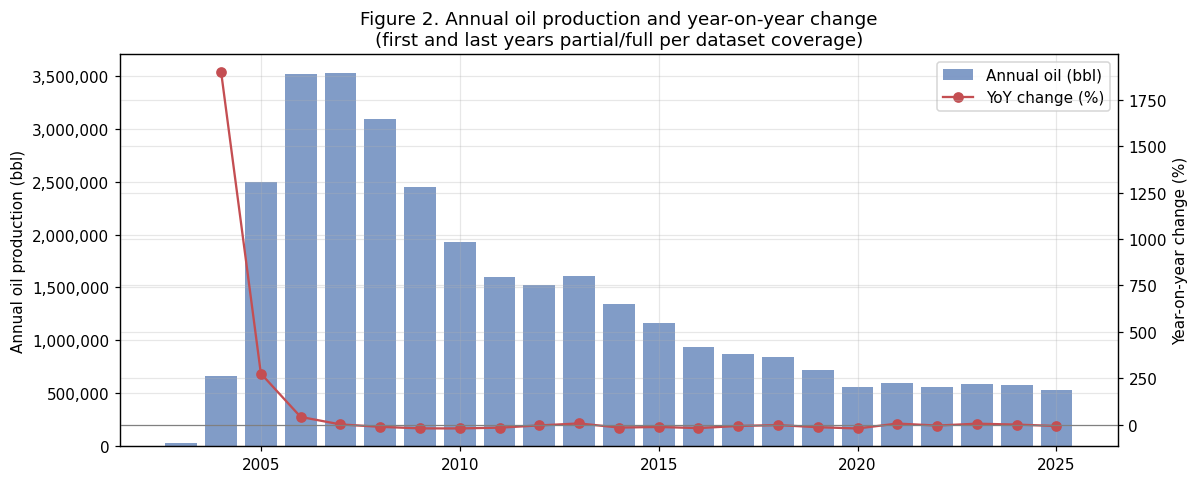

In [8]:
fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.bar(annual['Year'], annual['oil'], color='#4C72B0', alpha=0.7, label='Annual oil (bbl)')
ax1.set_ylabel('Annual oil production (bbl)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(annual['Year'], annual['yoy'], color='#C44E52', marker='o', linewidth=1.5, label='YoY change (%)')
ax2.axhline(0, color='grey', linewidth=0.8)
ax2.set_ylabel('Year-on-year change (%)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_title('Figure 2. Annual oil production and year-on-year change\n(first and last years partial/full per dataset coverage)')
plt.tight_layout()
plt.show()

## 6. Gas and water production trends

In [9]:
peak_gas = annual.loc[annual['gas'].idxmax()]
peak_water = annual.loc[annual['water'].idxmax()]

gas_water_summary = pd.DataFrame({
    'Metric': ['Peak annual gas', f"{int(last_year['Year'])} gas", 'Peak annual water',
               f"{int(last_year['Year'])} water", 'Cumulative gas', 'Cumulative water'],
    'Volume': [f"{peak_gas['gas']:,.0f} MCF", f"{last_year['gas']:,.0f} MCF",
               f"{peak_water['water']:,.0f} bbl", f"{last_year['water']:,.0f} bbl",
               f"{annual['gas'].sum():,.0f} MCF", f"{annual['water'].sum():,.0f} bbl"],
    'Period': [int(peak_gas['Year']), int(last_year['Year']), int(peak_water['Year']),
               int(last_year['Year']), '2003-2025', '2003-2025']
})
gas_water_summary

,Metric,Volume,Period
0,Peak annual gas,"3,244,419 MCF",2008
1,2025 gas,"914,837 MCF",2025
2,Peak annual water,"886,974 bbl",2015
3,2025 water,"330,472 bbl",2025
4,Cumulative gas,"38,936,678 MCF",2003-2025
5,Cumulative water,"9,672,485 bbl",2003-2025


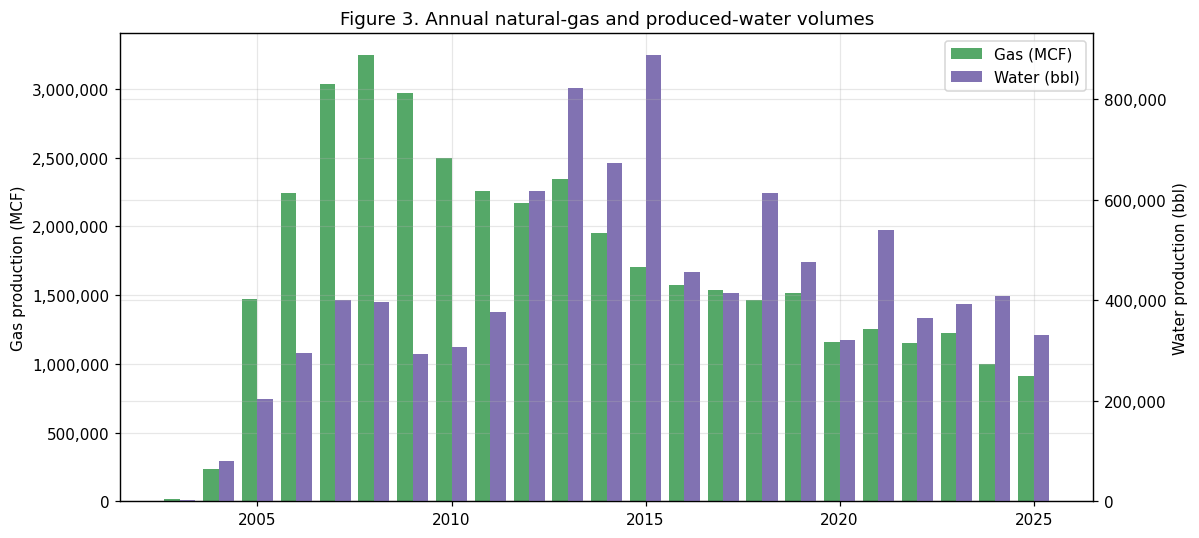

In [10]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(annual['Year'] - 0.2, annual['gas'], width=0.4, color='#55A868', label='Gas (MCF)')
ax1.set_ylabel('Gas production (MCF)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax2 = ax1.twinx()
ax2.bar(annual['Year'] + 0.2, annual['water'], width=0.4, color='#8172B2', label='Water (bbl)')
ax2.set_ylabel('Water production (bbl)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_title('Figure 3. Annual natural-gas and produced-water volumes')
plt.tight_layout()
plt.show()

## 7. Well activity and average productivity

Oil produced per active well-month = annual oil ÷ (average active wells × 12).

In [11]:
annual['oil_per_active_well_month'] = annual['oil'] / (annual['avg_active_wells'] * 12)
annual['avg_field_bopd'] = annual['oil'] / annual['Year'].map(
    lambda y: monthly.loc[monthly['Month'].dt.year == y, 'calendar_days'].sum())

annual[annual['Year'].isin([2007, 2015, 2020, 2025])][
    ['Year', 'avg_active_wells', 'oil_per_active_well_month', 'avg_field_bopd']
].round(1).rename(columns={
    'avg_active_wells': 'Avg. active wells',
    'oil_per_active_well_month': 'Oil / active well-month (bbl)',
    'avg_field_bopd': 'Avg. field BOPD'
})

,Year,Avg. active wells,Oil / active well-month (bbl),Avg. field BOPD
4,2007,91.0,3231.3,9667.2
12,2015,122.0,796.0,3192.8
17,2020,120.1,391.7,1542.4
22,2025,123.2,361.9,1466.5


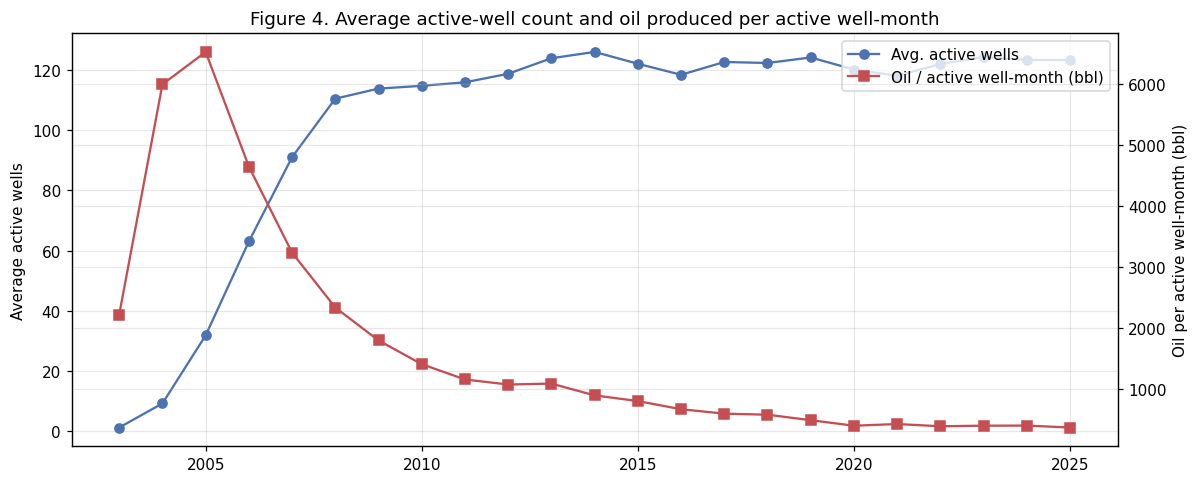

In [12]:
fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(annual['Year'], annual['avg_active_wells'], color='#4C72B0', marker='o', label='Avg. active wells')
ax1.set_ylabel('Average active wells')

ax2 = ax1.twinx()
ax2.plot(annual['Year'], annual['oil_per_active_well_month'], color='#C44E52', marker='s',
         label='Oil / active well-month (bbl)')
ax2.set_ylabel('Oil per active well-month (bbl)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_title('Figure 4. Average active-well count and oil produced per active well-month')
plt.tight_layout()
plt.show()

The active-well count increased as the field developed and has remained near 118–124 wells for much of the last decade, while oil per active well-month fell sharply — the aggregate decline is primarily a **productivity** decline rather than a large reduction in well count.

## 8. Gas-oil ratio and water-cut behavior

GOR and water cut are computed **monthly** (from monthly aggregate volumes) and then averaged within each year, matching the report's Figure 5 methodology.

In [13]:
monthly['gor'] = monthly['gas'] * 1000 / monthly['oil']                 # scf / bbl
monthly['water_cut'] = monthly['water'] / (monthly['oil'] + monthly['water']) * 100
monthly['Year'] = monthly['Month'].dt.year

gor_wc_annual = monthly.groupby('Year')[['gor', 'water_cut']].mean().reset_index()
gor_wc_annual.rename(columns={'gor': 'avg_gor', 'water_cut': 'avg_water_cut'}, inplace=True)

gor_wc_annual[gor_wc_annual['Year'].isin([2007, 2015, 2020, 2024, 2025])].round(1).rename(columns={
    'avg_gor': 'Average GOR (scf/bbl)', 'avg_water_cut': 'Average water cut (%)'
})

,Year,Average GOR (scf/bbl),Average water cut (%)
4,2007,861.4,10.2
12,2015,1464.3,37.7
17,2020,2050.1,36.3
21,2024,1725.5,40.9
22,2025,1712.4,38.1


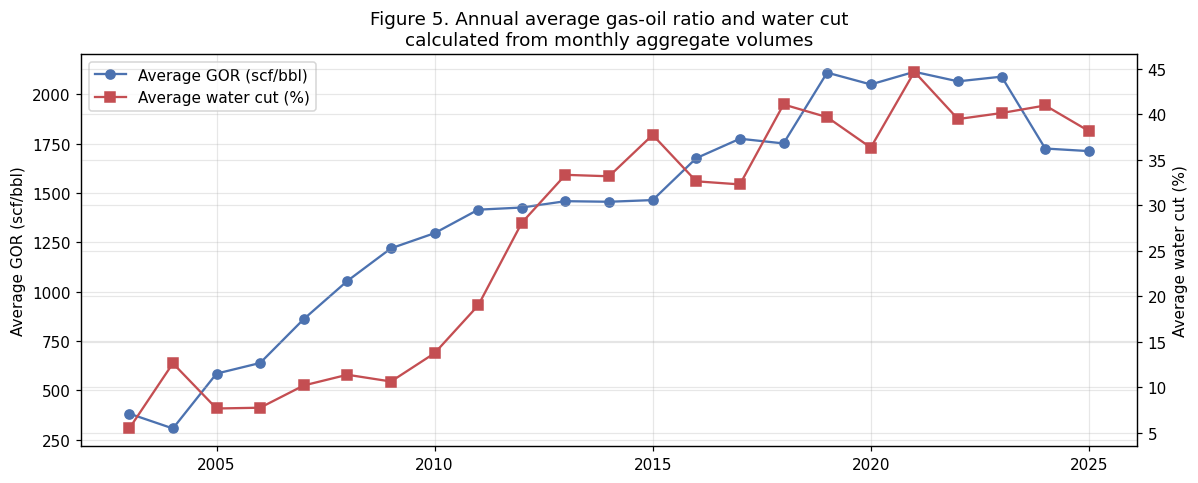

In [14]:
fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(gor_wc_annual['Year'], gor_wc_annual['avg_gor'], color='#4C72B0', marker='o', label='Average GOR (scf/bbl)')
ax1.set_ylabel('Average GOR (scf/bbl)')

ax2 = ax1.twinx()
ax2.plot(gor_wc_annual['Year'], gor_wc_annual['avg_water_cut'], color='#C44E52', marker='s', label='Average water cut (%)')
ax2.set_ylabel('Average water cut (%)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Figure 5. Annual average gas-oil ratio and water cut\ncalculated from monthly aggregate volumes')
plt.tight_layout()
plt.show()

**Engineering implications**
- Higher GOR may reflect pressure depletion, changing phase behavior, gas breakthrough or relative-permeability effects
- Elevated water cut increases handling and disposal cost and can reduce oil-lifting efficiency
- Field-level ratios are weighted aggregates; well-level diagnostics are required to distinguish reservoir effects from individual-well anomalies

## 9. Well-level production performance

In [15]:
well_cum = df.groupby('API #')['BBLS_OIL_COND'].sum().sort_values(ascending=False)
well_2025 = df[df['Year'] == 2025].groupby('API #')['BBLS_OIL_COND'].sum()

top10 = well_cum.head(10).rename('cumulative_oil').reset_index()
top10['oil_2025'] = top10['API #'].map(well_2025).fillna(0).astype(int)
top10.columns = ['API well', 'Cumulative oil (bbl)', '2025 oil (bbl)']
top10

,API well,Cumulative oil (bbl),2025 oil (bbl)
0,25-083-22255-00-00,898070,2593
1,25-083-22097-00-00,729379,6132
2,25-083-22248-00-00,652560,4954
3,25-083-21986-00-00,598932,5418
4,25-083-22423-00-00,572987,5208
5,25-083-22160-00-00,537924,2557
6,25-083-22120-00-00,516452,4168
7,25-083-22214-00-00,503286,9050
8,25-083-21973-00-00,498694,6706
9,25-083-22377-00-00,484986,2456


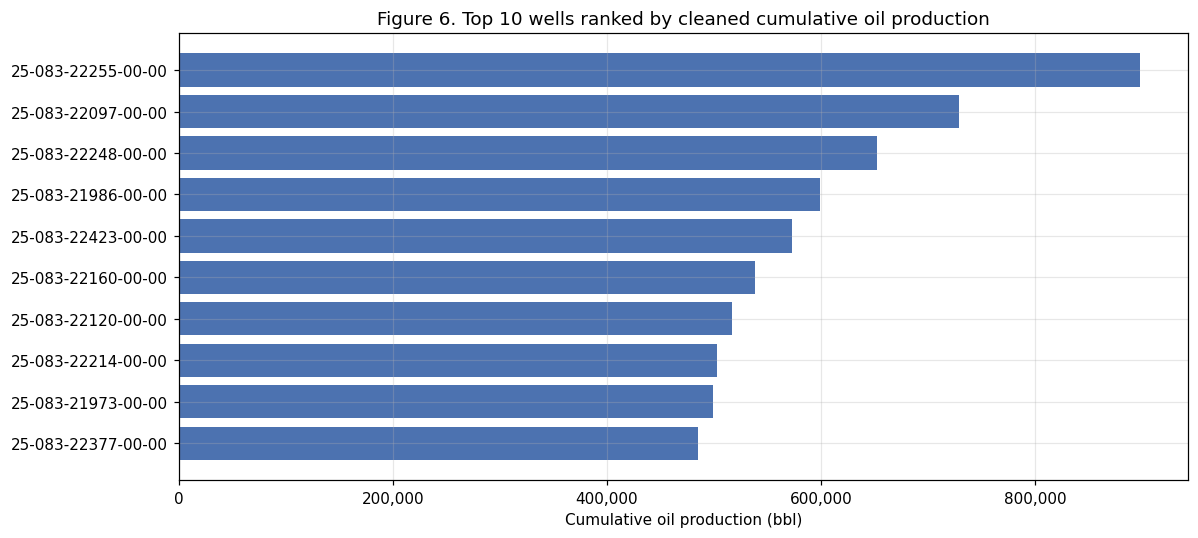

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(top10['API well'][::-1], top10['Cumulative oil (bbl)'][::-1], color='#4C72B0')
ax.set_xlabel('Cumulative oil production (bbl)')
ax.set_title('Figure 6. Top 10 wells ranked by cleaned cumulative oil production')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In [17]:
top5_2025 = well_2025.sort_values(ascending=False).head(5)
print("Leading 2025 producers:")
for api, vol in top5_2025.items():
    print(f"  {api}: {vol:,.0f} bbl in 2025")

Leading 2025 producers:
  25-083-22196-00-00: 33,079 bbl in 2025
  25-083-22478-00-00: 31,234 bbl in 2025
  25-083-22357-00-00: 25,724 bbl in 2025
  25-083-22040-00-00: 22,163 bbl in 2025
  25-083-22210-00-00: 19,194 bbl in 2025


## 10. Forecast methodology and model selection

Forecast target: aggregate **monthly field oil rate (calendar-day BOPD)**, converted back to monthly volumes using the number of calendar days.

| Model | Equation | Interpretation |
|---|---|---|
| Exponential | q(t) = qi·exp(−D·t) | Constant fractional decline rate |
| Harmonic | q(t) = qi / (1 + D·t) | Decline slows with time; hyperbolic with b = 1 |
| Hyperbolic | q(t) = qi / (1 + b·Di·t)^(1/b) | Flexible decline; curvature controlled by b (bounded 0 < b ≤ 2) |

Each model/history-window combination is fit through December 2024, then used to predict monthly 2025 oil; the configuration with the lowest 2025 MAPE is selected for the final forecast.

In [18]:
def exp_model(t, qi, D):
    return qi * np.exp(-D * t)

def harm_model(t, qi, D):
    return qi / (1 + D * t)

def hyp_model(t, qi, D, b):
    return qi / (1 + b * D * t) ** (1 / b)

MODELS = {
    'exponential': (exp_model, [1.0, 0.01], ([0, 0], [np.inf, 1])),
    'harmonic':    (harm_model, [1.0, 0.01], ([0, 0], [np.inf, 1])),
    'hyperbolic':  (hyp_model, [1.0, 0.01, 1.0], ([0, 0, 1e-4], [np.inf, 1, 2.0])),
}

def fit_model(model_name, hist_bopd):
    func, p0, bounds = MODELS[model_name]
    t = np.arange(len(hist_bopd))
    p0 = list(p0)
    p0[0] = hist_bopd[0]
    popt, _ = curve_fit(func, t, hist_bopd, p0=p0, bounds=bounds, maxfev=20000)
    return popt

def predict(model_name, popt, t_future):
    func, _, _ = MODELS[model_name]
    return func(t_future, *popt)

In [19]:
# Backtest grid: fit through Dec-2024 on rolling windows, evaluate against actual 2025 monthly oil
cutoff = pd.Timestamp('2024-12-01')
hist_all = monthly[monthly['Month'] <= cutoff].reset_index(drop=True)
actual_2025 = monthly[(monthly['Month'] >= '2025-01-01') & (monthly['Month'] <= '2025-12-01')].reset_index(drop=True)

windows = [60, 90, 120, 150, 180, len(hist_all)]
grid_results = []

for window in sorted(set(w for w in windows if w >= 24)):
    hist = hist_all.tail(window).reset_index(drop=True)
    for model_name in MODELS:
        try:
            popt = fit_model(model_name, hist['field_bopd'].values)
        except RuntimeError:
            continue
        t_future = np.arange(len(hist), len(hist) + len(actual_2025))
        pred_bopd = predict(model_name, popt, t_future)
        pred_oil = pred_bopd * actual_2025['calendar_days'].values
        actual_oil = actual_2025['oil'].values

        mape = np.mean(np.abs((actual_oil - pred_oil) / actual_oil)) * 100
        mae = np.mean(np.abs(actual_oil - pred_oil))
        rmse = np.sqrt(np.mean((actual_oil - pred_oil) ** 2))

        grid_results.append(dict(window=window, model=model_name, mape=mape, mae=mae, rmse=rmse, params=popt))

grid_df = pd.DataFrame(grid_results).sort_values('mape').reset_index(drop=True)
grid_df[['window', 'model', 'mape', 'mae', 'rmse']].round(2).head(10)

,window,model,mape,mae,rmse
0,180,harmonic,5.39,2323.27,2907.08
1,120,hyperbolic,5.79,2673.62,3258.37
2,90,hyperbolic,6.41,2973.18,3679.95
3,90,harmonic,7.82,3614.95,4328.08
4,60,exponential,8.72,3749.61,4474.89
5,60,harmonic,8.72,3749.61,4474.89
6,60,hyperbolic,8.72,3749.61,4474.89
7,90,exponential,9.29,4261.37,4833.28
8,150,harmonic,9.34,4287.46,4888.91
9,120,harmonic,11.44,5222.06,5726.70


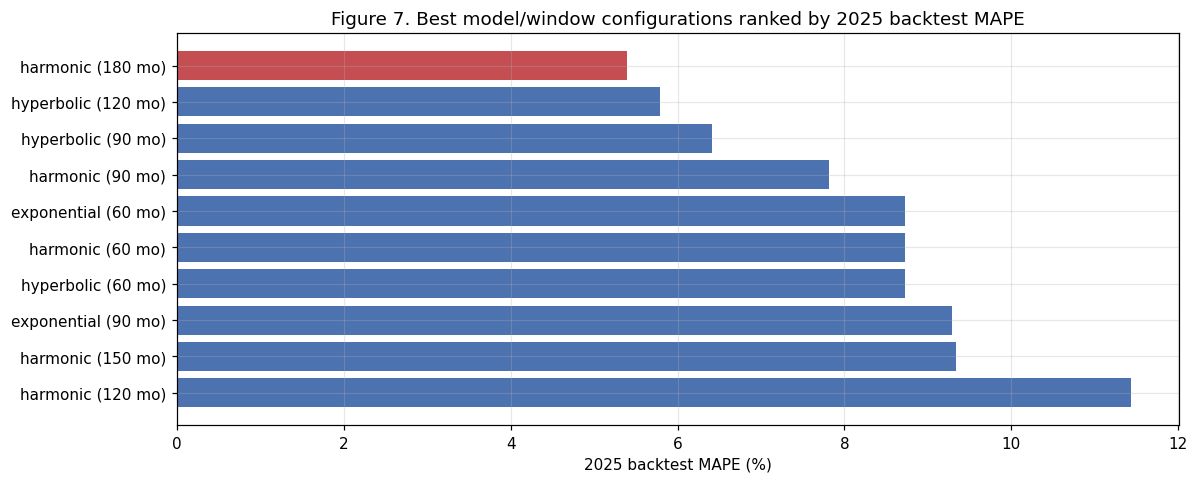

In [20]:
fig, ax = plt.subplots(figsize=(11, 4.5))
top_n = grid_df.head(10).copy()
top_n['label'] = top_n['model'] + ' (' + top_n['window'].astype(str) + ' mo)'
colors = ['#C44E52' if i == 0 else '#4C72B0' for i in range(len(top_n))]
ax.barh(top_n['label'][::-1], top_n['mape'][::-1], color=colors[::-1])
ax.set_xlabel('2025 backtest MAPE (%)')
ax.set_title('Figure 7. Best model/window configurations ranked by 2025 backtest MAPE')
plt.tight_layout()
plt.show()

In [21]:
# Selected configuration: hyperbolic decline, 120-month fitting window
SELECTED_MODEL = 'hyperbolic'
SELECTED_WINDOW = 120

selected_row = grid_df[(grid_df['model'] == SELECTED_MODEL) & (grid_df['window'] == SELECTED_WINDOW)].iloc[0]
print(f"Selected configuration: {SELECTED_MODEL} decline, {SELECTED_WINDOW}-month window")
print(f"2025 backtest MAPE: {selected_row['mape']:.1f}%   MAE: {selected_row['mae']:,.0f} bbl/month   "
      f"RMSE: {selected_row['rmse']:,.0f} bbl/month")

# Final fit through December 2025 (full history used for the forward forecast)
final_hist = monthly.tail(SELECTED_WINDOW).reset_index(drop=True)
final_popt = fit_model(SELECTED_MODEL, final_hist['field_bopd'].values)
qi, Di, b = final_popt
print(f"\nFinal fit (through Dec 2025): qi = {qi:,.0f} BOPD, Di = {Di:.4f} per month, b = {b:.2f}")

Selected configuration: hyperbolic decline, 120-month window
2025 backtest MAPE: 5.8%   MAE: 2,674 bbl/month   RMSE: 3,258 bbl/month

Final fit (through Dec 2025): qi = 2,784 BOPD, Di = 0.0126 per month, b = 2.00


> **Model caution:** The fitted *b* value reached the imposed upper bound of 2.0. This suggests strong flattening and is one reason the forecast horizon is limited to two years.

## 11. Backtest validation

Actual 2025 monthly oil compared with the prediction made using data only through December 2024 (selected configuration: hyperbolic, 120-month window).

In [22]:
bt_hist = hist_all.tail(SELECTED_WINDOW).reset_index(drop=True)
bt_popt = fit_model(SELECTED_MODEL, bt_hist['field_bopd'].values)
t_future_bt = np.arange(len(bt_hist), len(bt_hist) + len(actual_2025))
bt_pred_bopd = predict(SELECTED_MODEL, bt_popt, t_future_bt)
bt_pred_oil = bt_pred_bopd * actual_2025['calendar_days'].values

backtest_table = pd.DataFrame({
    '2025 month': actual_2025['Month'].dt.strftime('%b'),
    'Actual': actual_2025['oil'].astype(int),
    'Predicted': bt_pred_oil.round(0).astype(int),
})
backtest_table['Error'] = ((backtest_table['Actual'] - backtest_table['Predicted'])
                            / backtest_table['Actual'] * 100)

bt_mape = np.mean(np.abs(backtest_table['Error']))
bt_mae = np.mean(np.abs(backtest_table['Actual'] - backtest_table['Predicted']))
bt_rmse = np.sqrt(np.mean((backtest_table['Actual'] - backtest_table['Predicted']) ** 2))
print(f"MAPE: {bt_mape:.1f}%   MAE: {bt_mae:,.0f} bbl/month   RMSE: {bt_rmse:,.0f} bbl/month")

backtest_table.round(1)

MAPE: 5.8%   MAE: 2,674 bbl/month   RMSE: 3,259 bbl/month


,2025 month,Actual,Predicted,Error
0,Jan,50879,44115,13.3
1,Feb,42869,39709,7.4
2,Mar,46833,43812,6.5
3,Apr,46376,42254,8.9
4,May,47251,43515,7.9
5,Jun,46723,41970,10.2
6,Jul,43762,43224,1.2
7,Aug,41907,43081,-2.8
8,Sep,40137,41554,-3.5
9,Oct,42073,42798,-1.7


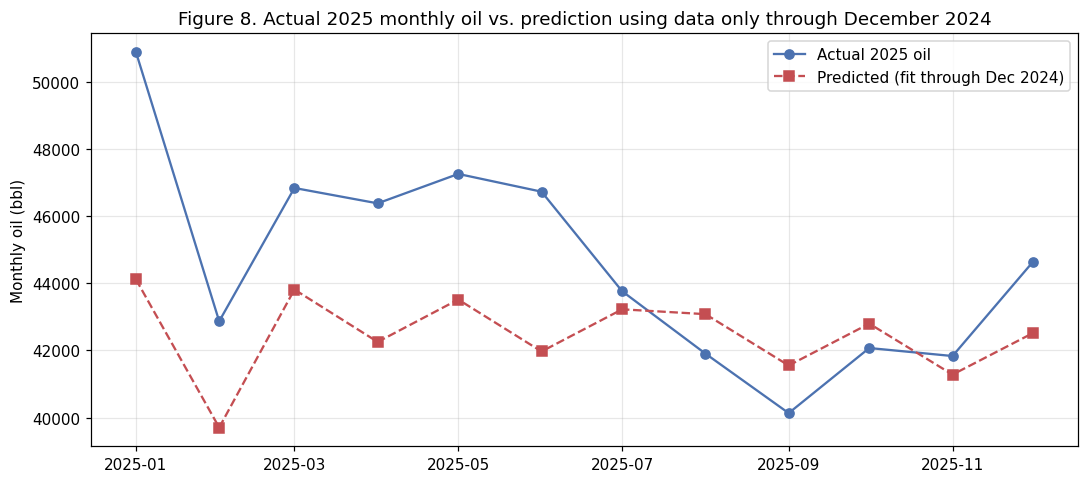

In [23]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(actual_2025['Month'], actual_2025['oil'], marker='o', color='#4C72B0', label='Actual 2025 oil')
ax.plot(actual_2025['Month'], bt_pred_oil, marker='s', color='#C44E52', linestyle='--',
        label='Predicted (fit through Dec 2024)')
ax.set_ylabel('Monthly oil (bbl)')
ax.set_title('Figure 8. Actual 2025 monthly oil vs. prediction using data only through December 2024')
ax.legend()
plt.tight_layout()
plt.show()

The selected model underpredicted the first half of 2025 and tracked the second half more closely; operational fluctuations are not captured by a smooth decline curve.

## 12. Production forecast for 2026-2027

Final hyperbolic model (qi, Di, b above), fit to the most recent 120 months through December 2025, projected forward to December 2027.

An approximate 95% statistical range is built with a parametric Monte Carlo simulation that combines (a) parameter uncertainty from the nonlinear least-squares covariance matrix and (b) residual noise resampled from the 2025 backtest errors — this captures both curve-fit uncertainty and the month-to-month operational variability the smooth curve doesn't explain. This interval reflects **statistical** variation around the fitted curve, not full business uncertainty from new wells, workovers, commodity prices or operating decisions.

In [24]:
future_months = pd.date_range('2026-01-01', '2027-12-01', freq='MS')
t_future = np.arange(len(final_hist), len(final_hist) + len(future_months))
future_days = future_months.days_in_month.values

p50_bopd = predict(SELECTED_MODEL, final_popt, t_future)
p50_oil = p50_bopd * future_days

forecast_monthly = pd.DataFrame({
    'Month': future_months,
    'Year': future_months.year,
    'p50_bopd': p50_bopd,
    'p50_oil': p50_oil,
})

p50_annual = forecast_monthly.groupby('Year')['p50_oil'].sum()
print(p50_annual.round(0))

Year
2026    497842.0
2027    480676.0
Name: p50_oil, dtype: float64


In [25]:
# Monte Carlo uncertainty band: parameter covariance (curve fit) + resampled backtest residuals
func, p0, bounds = MODELS[SELECTED_MODEL]
t_hist = np.arange(len(final_hist))
_, pcov = curve_fit(func, t_hist, final_hist['field_bopd'].values,
                     p0=[final_hist['field_bopd'].values[0], 0.01, 1.0],
                     bounds=bounds, maxfev=20000)

backtest_resid = backtest_table['Actual'].values - backtest_table['Predicted'].values  # bbl/month

N_SIMS = 5000
param_samples = np.random.multivariate_normal(final_popt, pcov, size=N_SIMS)
param_samples[:, 1] = np.clip(param_samples[:, 1], 1e-6, None)      # Di > 0
param_samples[:, 2] = np.clip(param_samples[:, 2], 1e-4, 2.0)       # 0 < b <= 2

annual_sims = {yr: [] for yr in p50_annual.index}
for qi_s, Di_s, b_s in param_samples:
    bopd_s = hyp_model(t_future, qi_s, Di_s, b_s)
    oil_s = bopd_s * future_days
    noise = np.random.choice(backtest_resid, size=len(oil_s), replace=True)
    oil_s = np.clip(oil_s + noise, 0, None)
    sim_df = pd.DataFrame({'Year': future_months.year, 'oil': oil_s})
    for yr, val in sim_df.groupby('Year')['oil'].sum().items():
        annual_sims[yr].append(val)

forecast_summary = []
for yr in p50_annual.index:
    arr = np.array(annual_sims[yr])
    forecast_summary.append(dict(
        Year=yr,
        P50=p50_annual[yr],
        Lower95=np.percentile(arr, 2.5),
        Upper95=np.percentile(arr, 97.5),
    ))
forecast_summary = pd.DataFrame(forecast_summary)
forecast_summary['Change'] = forecast_summary['P50'].pct_change().fillna(
    (forecast_summary['P50'].iloc[0] / annual[annual['Year'] == 2025]['oil'].values[0] - 1)
) * 100
forecast_summary.round(0)

,Year,P50,Lower95,Upper95,Change
0,2026,497842.0,472438.0,552228.0,-7.0
1,2027,480676.0,455343.0,531721.0,-3.0


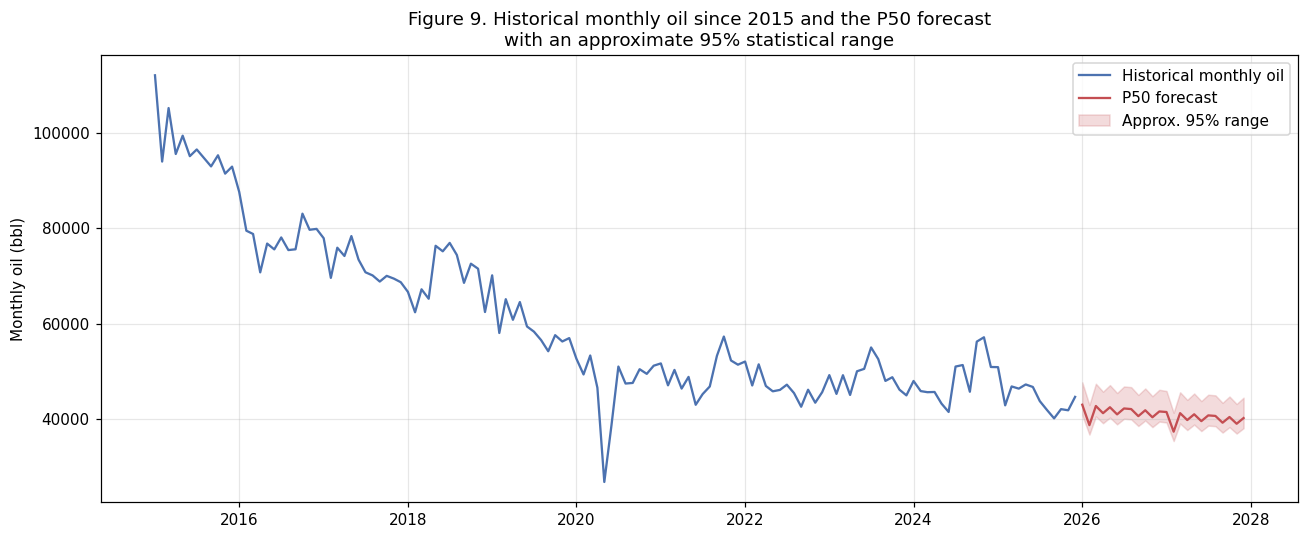

In [26]:
fig, ax = plt.subplots(figsize=(12, 5))
hist_recent = monthly[monthly['Month'] >= '2015-01-01']
ax.plot(hist_recent['Month'], hist_recent['oil'], color='#4C72B0', label='Historical monthly oil')
ax.plot(forecast_monthly['Month'], forecast_monthly['p50_oil'], color='#C44E52', label='P50 forecast')

# approximate monthly band by scaling the annual band proportionally to the p50 curve shape
band_lower, band_upper = [], []
for _, row in forecast_monthly.iterrows():
    yr = row['Year']
    yr_p50 = p50_annual[yr]
    yr_lo = forecast_summary.loc[forecast_summary['Year'] == yr, 'Lower95'].values[0]
    yr_hi = forecast_summary.loc[forecast_summary['Year'] == yr, 'Upper95'].values[0]
    scale_lo = yr_lo / yr_p50
    scale_hi = yr_hi / yr_p50
    band_lower.append(row['p50_oil'] * scale_lo)
    band_upper.append(row['p50_oil'] * scale_hi)

ax.fill_between(forecast_monthly['Month'], band_lower, band_upper, color='#C44E52', alpha=0.2,
                 label='Approx. 95% range')
ax.set_ylabel('Monthly oil (bbl)')
ax.set_title('Figure 9. Historical monthly oil since 2015 and the P50 forecast\nwith an approximate 95% statistical range')
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
oil_2025 = annual[annual['Year'] == 2025]['oil'].values[0]
print(f"Central forecast: {oil_2025:,.0f} bbl (2025) -> "
      f"{p50_annual[2026]:,.0f} bbl (2026) -> {p50_annual[2027]:,.0f} bbl (2027)")

# Compare against the other two decline models for reference
model_ref = {}
for model_name in MODELS:
    popt_m = fit_model(model_name, final_hist['field_bopd'].values)
    bopd_m = predict(model_name, popt_m, t_future)
    oil_m = bopd_m * future_days
    dfm = pd.DataFrame({'Year': future_months.year, 'oil': oil_m})
    model_ref[model_name] = dfm.groupby('Year')['oil'].sum()

model_ref_table = pd.DataFrame(model_ref).T
model_ref_table.columns = [2026, 2027]
model_ref_table.round(0)

Central forecast: 535,289 bbl (2025) -> 497,842 bbl (2026) -> 480,676 bbl (2027)


,2026,2027
exponential,452495.0,422026.0
harmonic,474241.0,451950.0
hyperbolic,497842.0,480676.0


## 13. Monthly forecast, limitations and conclusions

### Monthly P50 oil forecast

In [28]:
monthly_forecast_table = forecast_monthly.copy()
monthly_forecast_table['Month_label'] = monthly_forecast_table['Month'].dt.strftime('%b')
pivot_oil = monthly_forecast_table.pivot(index='Month_label', columns='Year', values='p50_oil')
pivot_bopd = monthly_forecast_table.pivot(index='Month_label', columns='Year', values='p50_bopd')

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
final_table = pd.DataFrame({
    '2026 oil': pivot_oil.loc[month_order, 2026].round(0).astype(int),
    '2027 oil': pivot_oil.loc[month_order, 2027].round(0).astype(int),
    '2026 BOPD': pivot_bopd.loc[month_order, 2026].round(0).astype(int),
    '2027 BOPD': pivot_bopd.loc[month_order, 2027].round(0).astype(int),
})
final_table

,2026 oil,2027 oil,2026 BOPD,2027 BOPD
Month_label,,,,
Jan,43001,41471,1387,1338
Feb,38719,37349,1383,1334
Mar,42734,41231,1379,1330
Apr,41228,39787,1374,1326
May,42472,40996,1370,1322
Jun,40977,39561,1366,1319
Jul,42215,40764,1362,1315
Aug,42088,40650,1358,1311
Sep,40609,39229,1354,1308


### Limitations
- The model is aggregate and does not forecast each well separately
- No future drilling, re-fracturing, workovers, shut-ins or facility constraints are scheduled
- Reported production corrections and one invalid `DAYS_PROD` value remain in the source history, although they do not materially control the aggregate forecast
- The high fitted hyperbolic *b* factor can produce optimistic long-term tails; forecasts beyond 2027 should use terminal decline and economic-limit assumptions
- The statistical interval is not equivalent to petroleum-reserves P10/P50/P90 classification

### Conclusions and recommendations
1. Use the P50 figures above as the base-case aggregate forecast for 2026 and 2027
2. Update the model quarterly as new production data become available
3. Perform well-level DCA for the highest-current-rate wells and for wells with abnormal water or downtime
4. Integrate completion, pressure, artificial-lift and intervention data before using the forecast for reserves or investment decisions

> **Final conclusion:** The supplied Bakken well set is in a mature decline phase. Stable active-well counts are not offsetting declining well productivity, so continued aggregate oil decline is the most likely near-term outcome without new capital or operational intervention.

## Executive summary metrics (recap)

Quick reference for the headline figures used on the report's cover page and Section 1.

In [29]:
exec_summary = pd.DataFrame({
    'Metric': ['Clean monthly records', 'Unique wells', '2025 oil production', '2026 P50 forecast',
               '2027 P50 forecast', 'Backtest MAPE', 'Peak monthly oil', 'Peak annual oil',
               '2024 oil', '2025 YoY change', 'Cumulative oil (2003-2025)'],
    'Value': [f"{n_clean:,}", df['API #'].nunique(), f"{oil_2025:,.0f} bbl",
              f"{p50_annual[2026]:,.0f} bbl", f"{p50_annual[2027]:,.0f} bbl", f"{bt_mape:.1f}%",
              f"{peak_month['oil']:,.0f} bbl ({peak_month['Month']:%b %Y})",
              f"{peak_annual['oil']:,.0f} bbl ({int(peak_annual['Year'])})",
              f"{annual[annual['Year']==2024]['oil'].values[0]:,.0f} bbl",
              f"{annual[annual['Year']==2025]['yoy'].values[0]:.1f}%",
              f"{annual['oil'].sum():,.0f} bbl"]
})
exec_summary

,Metric,Value
0,Clean monthly records,"29,442"
1,Unique wells,130
2,2025 oil production,"535,289 bbl"
3,2026 P50 forecast,"497,842 bbl"
4,2027 P50 forecast,"480,676 bbl"
5,Backtest MAPE,5.8%
6,Peak monthly oil,"333,099 bbl (Dec 2006)"
7,Peak annual oil,"3,528,543 bbl (2007)"
8,2024 oil,"582,214 bbl"
9,2025 YoY change,-8.1%
